In [1]:
import importlib

In [2]:
import paper_dataset
# importlib.reload(paper_dataset)

In [3]:
ds = paper_dataset.load('data/tokenization_papers_with_category.jsonl')

In [4]:
ds.shape

(149355, 19)

In [5]:
evaluation = ds[ds['evaluation'] == True]   
tokenization = ds[ds['tokenization'] == True]
application = ds[ds['application'] == True]
survey = ds[ds['survey'] == True]
topic = ds[ds['topic'] == True]

In [13]:
survey.columns

Index(['bibtex_id', 'title', 'author', 'year', 'abstract', 'type', 'url',
       'pdf_url', 'volume', 'tldr', 'keywords', 'research_area', 'venue',
       'topic', 'tokenization', 'evaluation', 'application', 'survey',
       'exclude'],
      dtype='object')

In [16]:
import pandas as pd 

tmp_tokenization = tokenization[['type', 'bibtex_id', 'title', 'author', 'year', 'url','pdf_url', 'venue', 'volume']].rename(columns={'type': 'source'})
tmp_evaluation = evaluation[['type', 'bibtex_id', 'title', 'author', 'year', 'url','pdf_url', 'venue', 'volume']].rename(columns={'type': 'source'})
tmp_survey= survey[['type', 'bibtex_id', 'title', 'author', 'year', 'url','pdf_url', 'venue', 'volume']].rename(columns={'type': 'source'})
tmp_application = application[['type', 'bibtex_id', 'title', 'author', 'year', 'url','pdf_url', 'venue', 'volume']].rename(columns={'type': 'source'})

with pd.ExcelWriter('tmp.xlsx', engine='xlsxwriter') as writer:
    tmp_tokenization.to_excel(writer, index=False, sheet_name='tokenizers')
    tmp_evaluation.to_excel(writer, index=False, sheet_name='evaluations')
    tmp_survey.to_excel(writer, index=False, sheet_name='surveys')  
    tmp_application.to_excel(writer, index=False, sheet_name='applications')


In [8]:
real_survey = survey.iloc[[1, 2, 3, 4, 7, 13, 16, 23, 24, 28, 50]]

In [12]:
topic['real_survey'] = topic.index.isin(real_survey.index)

/tmp/ipykernel_2589914/2046663385.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  topic['real_survey'] = topic.index.isin(real_survey.index)


In [13]:
print("tokenization=True, evaluation=True, survey=True:", topic[(topic['tokenization'] == True) & (topic['evaluation'] == True) & (topic['real_survey'] == True)].shape[0])
print("tokenization=True, evaluation=True, survey=False:", topic[(topic['tokenization'] == True) & (topic['evaluation'] == True) & (topic['real_survey'] == False)].shape[0])
print("tokenization=True, evaluation=False, survey=True:", topic[(topic['tokenization'] == True) & (topic['evaluation'] == False) & (topic['real_survey'] == True)].shape[0])
print("tokenization=True, evaluation=False, survey=False:", topic[(topic['tokenization'] == True) & (topic['evaluation'] == False) & (topic['real_survey'] == False)].shape[0])
print("tokenization=False, evaluation=True, survey=True:", topic[(topic['tokenization'] == False) & (topic['evaluation'] == True) & (topic['real_survey'] == True)].shape[0])
print("tokenization=False, evaluation=True, survey=False:", topic[(topic['tokenization'] == False) & (topic['evaluation'] == True) & (topic['real_survey'] == False)].shape[0])
print("tokenization=False, evaluation=False, survey=True:", topic[(topic['tokenization'] == False) & (topic['evaluation'] == False) & (topic['real_survey'] == True)].shape[0])
print("tokenization=False, evaluation=False, survey=False:", topic[(topic['tokenization'] == False) & (topic['evaluation'] == False) & (topic['real_survey'] == False)].shape[0])

tokenization=True, evaluation=True, survey=True: 1
tokenization=True, evaluation=True, survey=False: 23
tokenization=True, evaluation=False, survey=True: 1
tokenization=True, evaluation=False, survey=False: 850
tokenization=False, evaluation=True, survey=True: 5
tokenization=False, evaluation=True, survey=False: 149
tokenization=False, evaluation=False, survey=True: 4
tokenization=False, evaluation=False, survey=False: 2368


In [16]:
topic[(topic['tokenization'] == True) & (topic['evaluation'] == True) & (topic['real_survey'] == True)]

,bibtex_id,title,author,year,abstract,type,url,pdf_url,volume,tldr,keywords,research_area,venue,topic,tokenization,evaluation,application,survey,exclude,real_survey
3582,imamura-utiyama-2024-empirical,An Empirical Study of Multilingual Vocabulary ...,"Imamura, Kenji and Utiyama, Masao",2024,"In this paper, we discuss multilingual vocabul...",acl,https://aclanthology.org/2024.wat-1.2/,https://aclanthology.org/2024.wat-1.2.pdf,Proceedings of the Eleventh Workshop on Asian ...,None,None,None,WAT,1.0,1.0,1.0,0.0,1.0,0.0,True


In [17]:
topic[(topic['tokenization'] == True) & (topic['evaluation'] == False) & (topic['real_survey'] == True)]

,bibtex_id,title,author,year,abstract,type,url,pdf_url,volume,tldr,keywords,research_area,venue,topic,tokenization,evaluation,application,survey,exclude,real_survey
3097,doyle-mccrae-2025-assessment,An Assessment of Word Separation Practices in ...,"Doyle, Adrian and McCrae, John P.",2025,The quantity of Old Irish text which survives ...,acl,https://aclanthology.org/2025.cltw-1.1/,https://aclanthology.org/2025.cltw-1.1.pdf,Proceedings of the 5th Celtic Language Technol...,None,None,None,None,1.0,1.0,0.0,0.0,1.0,0.0,True


In [39]:
topic['type'].unique()

array(['acl', 'neurips', 'icml', 'iclr', 'colm'], dtype=object)

In [14]:
topic.volume.unique()

array(['Proceedings of the 4th Workshop on Arabic Corpus Linguistics (WACL-4)',
       'Proceedings of the 12th Workshop on NLP for Similar Languages, Varieties and Dialects',
       'Transactions of the Association for Computational Linguistics',
       'Proceedings of the Second Workshop on Scaling Up Multilingual {\\&} Multi-Cultural Evaluation',
       'Proceedings of the Second Workshop in South East Asian Language Processing',
       'Proceedings of the Third Workshop on Resources and Representations for Under-Resourced Languages and Domains (RESOURCEFUL-2025)',
       'Proceedings of the 10th Workshop on Representation Learning for NLP (RepL4NLP-2025)',
       'Proceedings of the Joint 25th Nordic Conference on Computational Linguistics and 11th Baltic Conference on Human Language Technologies (NoDaLiDa/Baltic-HLT 2025)',
       'Proceedings of the 5th International Conference on Natural Language Processing for Digital Humanities',
       'Proceedings of the 2025 Conference of t

In [10]:
topic[['volume', 'venue']]

,volume,venue
35,Proceedings of the 4th Workshop on Arabic Corp...,None
53,Proceedings of the 12th Workshop on NLP for Si...,None
99,Transactions of the Association for Computatio...,None
111,Proceedings of the Second Workshop on Scaling ...,None
122,Proceedings of the Second Workshop in South Ea...,None
...,...,...
149324,First Conference on Language Modeling,COLM
149343,First Conference on Language Modeling,COLM
149348,First Conference on Language Modeling,COLM
149353,First Conference on Language Modeling,COLM


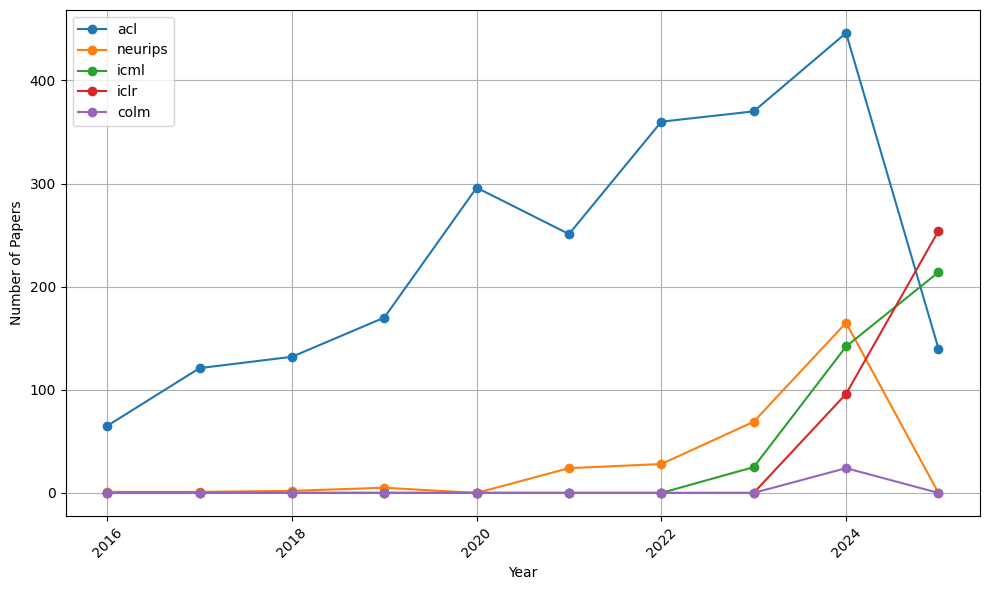

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import seaborn as sns
# Plot graph with the number of papers for each type ('type' column) over the years
# Plot the number of papers over the years for the top 5 languages
years = sorted(topic['year'].unique())
plt.figure(figsize=(10, 6))
for type in ['acl', 'neurips', 'icml', 'iclr', 'colm']:
    counts = []
    for year in years:
        counts.append(len(topic[(topic['year'] == year) & (topic['type'] == type)]))
    plt.plot(years, counts,  marker='o', label=type)
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
def make_tmp_venue(x):
    if x['venue'] is not None:
        if x['venue'] == 'COLM':
            return 'COLM'
        if 'ICLR' in x['venue']:
            return 'ICLR'
        if 'ICML' in x['venue']:
            return 'ICML'
        if x['venue'] =='RANLP':
            return 'RANLP'
        if 'neurips' in x['venue'].lower():
            return 'NeurIPS'
    if x['volume'] is not None:
        if 'LREC-COLING'.lower() in x['volume'].lower():
            return 'LREC-COLING'
        if 'Conference on Language Modeling'.lower() in x['volume'].lower():
            return 'COLM'
        if 'Americas Chapter of the Association for Computational Linguistics'.lower() in x['volume'].lower():
            return 'NAACL'
        if 'Transactions of the Association for Computational Linguistics'.lower() in x['volume'].lower():
            return 'TACL'
        if 'International Conference on Computational Linguistics'.lower() in x['volume'].lower():  
            return 'COLING'
        if 'EACL' in x['volume']:
            return 'EACL'
        if 'EMNLP' in x['volume']:
            return 'EMNLP'
        if ' ACL' in x['volume']:
            return 'ACL'
        if 'NAACL' in x['volume']:
            return 'NAACL'
        if 'Empirical Methods in Natural Language Processing'.lower() in x['volume'].lower():
            return 'EMNLP'
        if 'International Conference on Learning Representations'.lower() in x['volume'].lower():
            return 'ICLR'
        if 'International Conference on Machine Learning'.lower() in x['volume'].lower():
            return 'ICML'
        if 'Neural Information Processing Systems'.lower() in x['volume'].lower():
            return 'NeurIPS'

        if 'Annual Conference of the North American Chapter of the Association for Computational Linguistics'.lower() in x['volume'].lower():
            return 'NAACL'
        if 'Conference on Computational Natural Language Learning'.lower() in x['volume'].lower():
            return 'CoNLL'
        if 'International Conference on Natural Language Processing'.lower() in x['volume'].lower():
            return 'ICON'
        if 'International Joint Conference on Natural Language Processing'.lower() in x['volume'].lower():
            return 'IJCNLP'
        if 'International Conference on Computational Linguistics and Intelligent Text Processing'.lower() in x['volume'].lower():
            return 'CICLing'
        if 'International Conference on Recent Advances in Natural Language Processing'.lower() in x['volume'].lower():
            return 'RANLP'
        if 'Language Resources and Evaluation Conference'.lower() in x['volume'].lower():
            return 'LREC'
        if 'European Chapter of the Association for Computational Linguistics'.lower() in x['volume'].lower():
            return 'EACL'
        if 'International Conference on Natural Language Generation'.lower() in x['volume'].lower():
            return 'INLG'
        if 'International Natural Language Generation'.lower() in x['volume'].lower():
            return 'INLG'
        if 'Annual Meeting of the Association for Computational Linguistics'.lower() in x['volume'].lower():
            return 'ACL'
        if 'Conference of the North American Chapter of the Association for Computational Linguistics'.lower() in x['volume'].lower():
            return 'NAACL'
        if 'IJCNLP'.lower() in x['volume'].lower():
            return 'IJCNLP'
        if 'LREC'.lower() in x['volume'].lower():
            return 'LREC'
        if 'ICLR'.lower() in x['volume'].lower():   
            return 'ICLR'
        if 'International Conference on Spoken Language Translation'.lower() in x['volume'].lower():
            return 'IWSLT'
        
        if 'Conference on Machine Translation'.lower() in x['volume'].lower():
            return 'WMT'
        if '{ACL}' in x['volume']:
            return 'ACL'
        if '{C}o{NLL}' in x['volume']:
            return 'CoNLL'
        if 'North {A}merican Chapter of the Association for Computational Linguistics'.lower() in x['volume'].lower():
            return 'NAACL'
        if '{E}uropean Chapter of the Association for Computational'.lower() in x['volume'].lower():
            return 'EACL'
        if '{COLING}' in x['volume']:
            return 'COLING'
        if 'Computational Linguistics' == x['volume'] or 'Computational Linguistics.' == x['volume']:
            return 'CL'
    return x['volume']

In [32]:
tmp = topic.apply(make_tmp_venue, axis=1)
tmp

35        Proceedings of the 4th Workshop on Arabic Corp...
53        Proceedings of the 12th Workshop on NLP for Si...
99                                                     TACL
111       Proceedings of the Second Workshop on Scaling ...
122       Proceedings of the Second Workshop in South Ea...
                                ...                        
149324                                                 COLM
149343                                                 COLM
149348                                                 COLM
149353                                                 COLM
149354                                                 COLM
Length: 3401, dtype: object

In [33]:
counts = {
    'COLM': 0,
    'ICLR': 0,
    'ICML': 0,
    'RANLP': 0,
    'NeurIPS': 0,
    'NAACL': 0,
    'TACL': 0,
    'COLING': 0,
    'EACL': 0,
    'EMNLP': 0,
    'ACL': 0,
    'CoNLL': 0,
    'ICON': 0,
    'IJCNLP': 0,
    'CICLing': 0,
    'LREC': 0,
    'INLG': 0,
    'IWSLT': 0,
    'LREC-COLING': 0,
    'WMT': 0,
    'CL': 0,
    'Other': 0
}

for i in tmp.tolist():
    if i in counts:
        counts[i] += 1
    else:
        counts['Other'] += 1
counts

{'COLM': 24,
 'ICLR': 336,
 'ICML': 299,
 'RANLP': 19,
 'NeurIPS': 295,
 'NAACL': 190,
 'TACL': 31,
 'COLING': 127,
 'EACL': 47,
 'EMNLP': 466,
 'ACL': 379,
 'CoNLL': 48,
 'ICON': 39,
 'IJCNLP': 62,
 'CICLing': 0,
 'LREC': 118,
 'INLG': 10,
 'IWSLT': 23,
 'LREC-COLING': 77,
 'WMT': 52,
 'CL': 12,
 'Other': 747}

In [ ]:
# survey.to_json('data/survey_papers.jsonl', lines=True, orient='records')

In [ ]:
# survey_urls = survey.pdf_url.tolist()
# files = [paper_dataset.pdf_url_to_file(i) for i in survey_urls]
# with open('survey_papers.txt', 'w') as f:
#     f.write('\n'.join(files))

In [6]:
import tqdm
import time

In [7]:
for url in tqdm.tqdm(list(topic['pdf_url'])):
    try:
        if url == '':
            raise ValueError('Empty URL')
        paper_dataset.get_markdown(url, root='data/pdfs/')
        # time.sleep(0.5)
    except ValueError as e:
        print(e)

  2%|███▎                                                                                                                                                               | 70/3401 [02:18<1:12:23,  1.30s/it]

MuPDF error: syntax error: could not parse color space (426 0 R)

MuPDF error: syntax error: could not parse color space (426 0 R)

MuPDF error: syntax error: could not parse color space (426 0 R)

MuPDF error: syntax error: could not parse color space (426 0 R)

MuPDF error: syntax error: could not parse color space (426 0 R)

MuPDF error: syntax error: could not parse color space (426 0 R)

MuPDF error: syntax error: could not parse color space (426 0 R)

MuPDF error: syntax error: could not parse color space (426 0 R)



  2%|███▌                                                                                                                                                               | 74/3401 [02:29<1:56:09,  2.09s/it]

MuPDF error: library error: zlib error: incorrect header check

MuPDF error: library error: zlib error: incorrect header check

MuPDF error: library error: zlib error: incorrect header check

MuPDF error: library error: zlib error: incorrect header check

MuPDF error: library error: zlib error: incorrect header check

MuPDF error: library error: zlib error: incorrect header check

MuPDF error: library error: zlib error: incorrect header check

MuPDF error: library error: zlib error: incorrect header check

MuPDF error: library error: zlib error: incorrect header check

MuPDF error: library error: zlib error: incorrect header check

MuPDF error: library error: zlib error: incorrect header check

MuPDF error: library error: zlib error: incorrect header check

MuPDF error: library error: zlib error: incorrect header check

MuPDF error: library error: zlib error: unknown compression method

MuPDF error: library error: zlib error: incorrect header check

MuPDF error: library error: zlib err

 18%|█████████████████████████████▌                                                                                                                                      | 614/3401 [19:45<43:35,  1.07it/s]

...

 89%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                  | 3023/3401 [1:47:39<05:51,  1.08it/s]

Failed to download PDF from https://openreview.net/pdf/8ab07be227718c6fedf021b3871828329db76e60.pdf, status code: 404


 95%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌        | 3224/3401 [2:03:20<06:49,  2.31s/it]

Empty URL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3401/3401 [2:19:30<00:00,  2.46s/it]


In [18]:
application[application['pdf_url'] == ''].to_dict(orient='records')

[{'bibtex_id': 't4l8ObtHKo_hu2025finetuning',
  'title': "Fine-Tuning Token-Based Large Multimodal Models: What Works, What Doesn’t and What's Next",
  'author': 'Zhulin Hu and Yan Ma and Jiadi Su and Ethan Chern and Pengfei Liu',
  'year': 2025,
  'abstract': 'In this blog post, we explore the advancements and challenges in fine-tuning unified token-based large multimodal models, focusing on the Chameleon architecture and its fine-tuned variant, Anole. Released in 2024, these models exemplify a modern approach for integrating various data modalities through tokens, simplifying modal fusion and leveraging established techniques from large language models. The post details our research efforts to reveal what is important, what is mistaken, and what is worth exploring in future research during the fine-tuning process.',
  'type': 'iclr',
  'url': 'https://openreview.net/forum?id=t4l8ObtHKo',
  'pdf_url': '',
  'volume': 'The Fourth Blogpost Track at ICLR 2025',
  'tldr': None,
  'keyword

In [16]:
import json
import itertools
import re

In [21]:
def extract_units(output: str) -> list[str]:
    output = output.lower().strip()
    output = re.sub(r'\([^\(\)]*\) ?', '', output).strip() # remove parentheses with explanation
    output = re.sub(r'\.+$', '', output) # remove trailing dot
    
    if "," in output:
        output = output.split(",")        
    elif "\n" in output:
        output = output.split("\n")
    else:
        output = [output]
    items = [i.strip() for i in output]        
    items = [i.replace("and ", "") for i in items] # remove leading and
    items = [i for i in items if i != '']    
    units = sorted(list(set(items)))
    return units

In [2]:
with open('data/raw_answers/unit_answer.json') as f:
    all_answers_unit = json.load(f)

In [18]:
all_answers_unit[:10]

['Subwords, phonetic speech tokens (HuBERT), pitch tokens, style tokens, bytes, morphemes, pixels',
 'Tokens',
 'Subwords, characters, bytes',
 'Morphemes',
 'Words, tokens, characters, lemmas, sub-word tokens',
 'Morphemes, subwords, characters, words',
 'Words, opinion units, aspects, sentences, passages, excerpts.',
 'Morphemes',
 'Subwords, morphemes, words, characters',
 'Morphemes, characters, bytes, subwords, words, syllabic characters']

In [22]:
unit_sets = [extract_units(i) for i in all_answers_unit]

In [23]:
unit_sets[630:640]

[['actions',
  'characters',
  'instruction segments',
  'sub-tasks',
  'verbal phrases',
  'words'],
 ['characters', 'morphemes', 'words'],
 ['subwords'],
 ['frames', 'subwords'],
 ['characters', 'subwords'],
 ['characters', 'n-grams', 'skip-grams', 'subwords', 'words'],
 ['characters', 'consonants vowels', 'jamo', 'morphemes', 'subwords', 'words'],
 ['tokens'],
 ['pseudo tokens', 'sentences', 'tokens', 'words'],
 ['tokens']]

In [26]:
unique_units = set(itertools.chain.from_iterable(unit_sets))
len(unique_units)

1213

In [27]:
sorted(unique_units)

['* 2d bounding boxes',
 '* 2d information',
 '* 2d model control information',
 '* 2d model information',
 '* 2d object detection control information',
 '* 2d object detection information',
 '* 2d object editing control information',
 '* 2d object editing information',
 '* 2d pose control information',
 '* 2d pose information',
 '* 2d representations',
 '* 2d scene generation control information',
 '* 2d scene generation information',
 '* 2d-aware control information',
 '* 2d-aware editing control information',
 '* 2d-aware editing information',
 '* 2d-aware generation control information',
 '* 2d-aware generation information',
 '* 2d-aware information',
 '* 3d bounding boxes',
 '* 3d information',
 '* 3d model control information',
 '* 3d model information',
 '* 3d object detection control information',
 '* 3d object detection information',
 '* 3d object editing control information',
 '* 3d object editing information',
 '* 3d objects',
 '* 3d pose control information',
 '* 3d pose in